In [19]:
import numpy as np
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import torch.optim as optim
import matplotlib.pyplot as plt

In [20]:

# input:
#     content_image p
#     style_image a
#     pretrained VGG network
#     content_layer = conv4_2
#     style_layers = [conv1_1, conv2_1, conv3_1, conv4_1, conv5_1]
#     alpha, beta
#     style_weights w_l
#     num_steps

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print('Device used:', device)

#importing content and style images
content_image = Image.open('../images/val2017/river.jpg')
style_image = Image.open('../images/style/starry_night.jpg')

#resizing images to 256 by 256 pixels
raw_content_image = content_image.resize((512, 512), Image.Resampling.BICUBIC)
raw_style_image = style_image.resize((512, 512), Image.Resampling.BICUBIC)

to_tensor = transforms.ToTensor()
content_image = to_tensor(raw_content_image).unsqueeze(0).to(device)
style_image = to_tensor(raw_style_image).unsqueeze(0).to(device)

#importing pretrained vgg model
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device)

for param in vgg.parameters():
    param.requires_grad = False

content_layer = '21'   # conv4_2

style_layers = ['0', '5', '10', '19', '28']   # conv1_1 ... conv5_1
selected_layers = [content_layer] + style_layers


Device used: mps


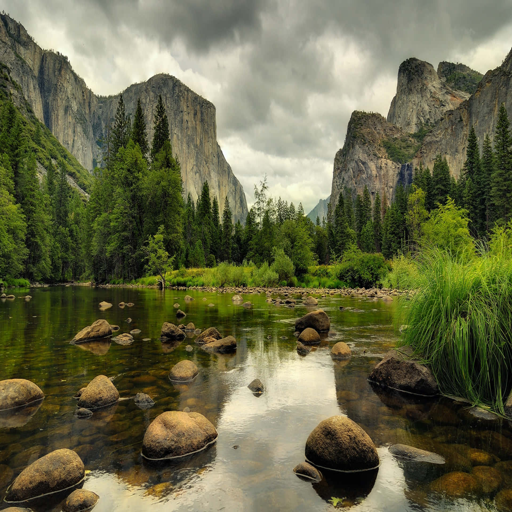

In [21]:
raw_content_image

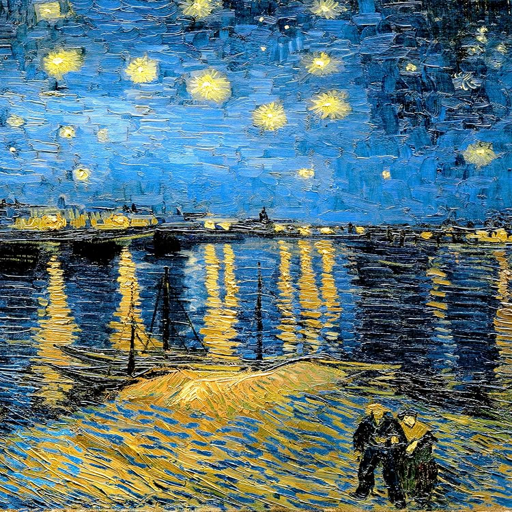

In [22]:
raw_style_image

In [23]:
def normalize_for_vgg(img):
    mean = torch.tensor([0.485, 0.456, 0.406], device=img.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=img.device).view(1, 3, 1, 1)
    return (img - mean) / std

In [24]:
def gram_matrix(features):
    _, C, H, W = features.shape
    F = features.view(C, H * W)
    G = torch.mm(F, F.t())
    return G / (C * H * W)

In [25]:
def extract_features(image, model, selected_layers):
    features = {}
    x = image
    
    for name, layer in model._modules.items():
        x = layer(x)
        if name in selected_layers:
            features[name] = x
            
    return features

In [26]:
content_activations = extract_features(
    normalize_for_vgg(content_image), vgg, selected_layers
)

style_activations = extract_features(
    normalize_for_vgg(style_image), vgg, selected_layers
)

content_target = content_activations[content_layer].detach()

style_targets = {}
for l in style_layers:
    style_targets[l] = gram_matrix(style_activations[l]).detach()

In [27]:
#initialize image x we want to generate
x = content_image.clone().to(device)
x.requires_grad_(True)

tensor([[[[0.7451, 0.7373, 0.7137,  ..., 0.5490, 0.5569, 0.5569],
          [0.7451, 0.7373, 0.7176,  ..., 0.5412, 0.5490, 0.5490],
          [0.7451, 0.7373, 0.7216,  ..., 0.5373, 0.5412, 0.5412],
          ...,
          [0.1686, 0.1686, 0.2588,  ..., 0.2118, 0.1843, 0.1804],
          [0.3490, 0.4471, 0.5294,  ..., 0.2588, 0.2118, 0.1490],
          [0.5843, 0.5725, 0.5608,  ..., 0.1725, 0.2157, 0.1647]],

         [[0.7529, 0.7451, 0.7216,  ..., 0.5725, 0.5804, 0.5804],
          [0.7529, 0.7451, 0.7255,  ..., 0.5647, 0.5725, 0.5725],
          [0.7529, 0.7451, 0.7294,  ..., 0.5608, 0.5647, 0.5647],
          ...,
          [0.1569, 0.1647, 0.2314,  ..., 0.1882, 0.1608, 0.1608],
          [0.3020, 0.4078, 0.4745,  ..., 0.2510, 0.1882, 0.1255],
          [0.5098, 0.5020, 0.5020,  ..., 0.1725, 0.1961, 0.1412]],

         [[0.7020, 0.6941, 0.6706,  ..., 0.5216, 0.5333, 0.5333],
          [0.7020, 0.6941, 0.6745,  ..., 0.5137, 0.5255, 0.5255],
          [0.7020, 0.6941, 0.6784,  ..., 0

In [28]:
def get_input_optimizer(input_img):
    input_img.requires_grad_(True)
    optimizer = optim.LBFGS([input_img])
    return optimizer

### Optimization

In [29]:
alpha = 1
beta = 1e6

w_l = 1/5

num_steps = 1000

optimizer = optim.LBFGS([x.requires_grad_()])

step = [0]

while step[0] < num_steps:

    def closure():
        optimizer.zero_grad()

        generated_activations = extract_features(
            normalize_for_vgg(x), vgg, selected_layers
        )

        #content loss
        F_content = generated_activations[content_layer]
        L_content = torch.mean((F_content - content_target) ** 2)

        #style loss
        L_style = 0
        for l in style_layers:
            F_style = generated_activations[l]

            G = gram_matrix(F_style)
            A = style_targets[l]

            E_layer = torch.mean((G - A)**2)
            L_style += w_l*E_layer

        L_total = alpha*L_content + beta*L_style

        L_total.backward()

        step[0] += 1

        if step[0] % 50 == 0:
            print(
                f"step {step[0]} | "
                f"content {L_content.item():.4f} | "
                f"style {L_style.item():.4e} | "
                f"weighted style {(beta*L_style).item():.4f} | "
                f"total {L_total.item():.4f}"
            )

        return L_total

    optimizer.step(closure)

    with torch.no_grad():
        x.clamp_(0, 1)

step 50 | content 3.2753 | style 3.3226e-06 | weighted style 3.3226 | total 6.5979
step 100 | content 2.5305 | style 1.3308e-06 | weighted style 1.3308 | total 3.8614
step 150 | content 2.3346 | style 1.0751e-06 | weighted style 1.0751 | total 3.4097
step 200 | content 2.1341 | style 9.8490e-07 | weighted style 0.9849 | total 3.1190
step 250 | content 2.0850 | style 9.4991e-07 | weighted style 0.9499 | total 3.0350
step 300 | content 2.0009 | style 9.2109e-07 | weighted style 0.9211 | total 2.9220
step 350 | content 1.9864 | style 9.1603e-07 | weighted style 0.9160 | total 2.9025
step 400 | content 1.9355 | style 8.9592e-07 | weighted style 0.8959 | total 2.8314
step 450 | content 1.9293 | style 9.2367e-07 | weighted style 0.9237 | total 2.8530
step 500 | content 1.8837 | style 8.8186e-07 | weighted style 0.8819 | total 2.7655
step 550 | content 1.8844 | style 8.9264e-07 | weighted style 0.8926 | total 2.7770
step 600 | content 1.8383 | style 8.7334e-07 | weighted style 0.8733 | total 

### Inference

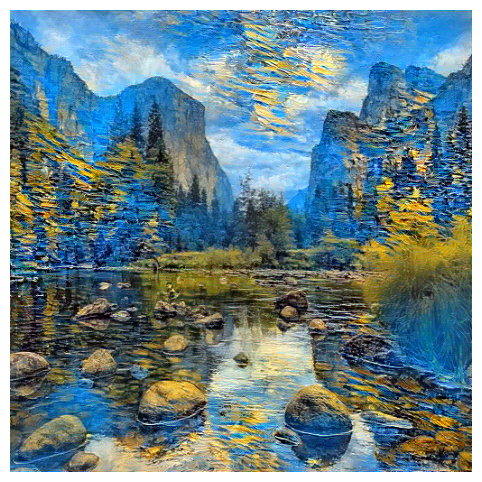

In [30]:
def tensor_to_image(tensor):
    image = tensor.detach().cpu().squeeze(0)
    image = image.clamp(0, 1)
    image = transforms.ToPILImage()(image)
    return image

result = tensor_to_image(x)

plt.figure(figsize=(10, 6))
plt.imshow(result)
plt.axis("off")
plt.show()

In [31]:
result.save("birdie_tsunami.png")